In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
from sklearn.decomposition import PCA
import joblib


In [2]:
data = pd.read_csv("D:/Projects/Kaggle/credit_scroring/CC GENERAL.csv")
data

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


Feature Selection

In [6]:
data_sel = data.drop(columns='CUST_ID')

In [7]:
# Spearmans correlation
spearman_corr = data_sel.corr(method='spearman')
spearman_corr

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
BALANCE,1.000000,0.544981,0.006473,0.145667,-0.089979,0.565888,-0.145210,0.119920,-0.144290,0.543966,0.549297,-0.046455,0.371896,0.431697,0.899816,-0.484347,0.065845
BALANCE_FREQUENCY,0.544981,1.000000,0.148170,0.134853,0.127641,0.137394,0.201921,0.159069,0.152037,0.177171,0.176223,0.202697,0.106422,0.207445,0.502487,-0.173999,0.228808
PURCHASES,0.006473,0.148170,1.000000,0.751164,0.705772,-0.384783,0.794568,0.692723,0.605821,-0.391195,-0.384261,0.885175,0.260778,0.394757,-0.007771,0.237636,0.132714
ONEOFF_PURCHASES,0.145667,0.134853,0.751164,1.000000,0.200484,-0.184628,0.423691,0.952447,0.117228,-0.179369,-0.175499,0.589997,0.304537,0.363263,0.070242,0.048545,0.096308
INSTALLMENTS_PURCHASES,-0.089979,0.127641,0.705772,0.200484,1.000000,-0.356848,0.786466,0.185454,0.923446,-0.366070,-0.357500,0.784309,0.123461,0.238554,-0.051883,0.276268,0.124960
CASH_ADVANCE,0.565888,0.137394,-0.384783,-0.184628,-0.356848,1.000000,-0.453686,-0.188825,-0.378224,0.940758,0.951837,-0.408235,0.162668,0.257280,0.481622,-0.265789,-0.112775
PURCHASES_FREQUENCY,-0.145210,0.201921,0.794568,0.423691,0.786466,-0.453686,1.000000,0.462957,0.851551,-0.452967,-0.446533,0.923591,0.104025,0.171995,-0.103692,0.292038,0.098109
ONEOFF_PURCHASES_FREQUENCY,0.119920,0.159069,0.692723,0.952447,0.185454,-0.188825,0.462957,1.000000,0.112436,-0.176216,-0.174263,0.606524,0.282193,0.320570,0.051143,0.061001,0.083880
PURCHASES_INSTALLMENTS_FREQUENCY,-0.144290,0.152037,0.605821,0.117228,0.923446,-0.378224,0.851551,0.112436,1.000000,-0.381854,-0.374158,0.780681,0.047366,0.120758,-0.084884,0.258941,0.114115
CASH_ADVANCE_FREQUENCY,0.543966,0.177171,-0.391195,-0.179369,-0.366070,0.940758,-0.452967,-0.176216,-0.381854,1.000000,0.983414,-0.407341,0.088479,0.202794,0.455822,-0.286991,-0.131003


Feature Selection

In [8]:
features = ['BALANCE','BALANCE_FREQUENCY','PURCHASES','ONEOFF_PURCHASES','INSTALLMENTS_PURCHASES','CASH_ADVANCE','CREDIT_LIMIT','PAYMENTS','PRC_FULL_PAYMENT','TENURE']
data_feat = data[features]
data_feat

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,1000.0,201.802084,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,7000.0,4103.032597,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,7500.0,622.066742,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,7500.0,0.000000,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,1200.0,678.334763,0.000000,12
...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,291.12,0.00,291.12,0.000000,1000.0,325.594462,0.500000,6
8946,19.183215,1.000000,300.00,0.00,300.00,0.000000,1000.0,275.861322,0.000000,6
8947,23.398673,0.833333,144.40,0.00,144.40,0.000000,1000.0,81.270775,0.250000,6
8948,13.457564,0.833333,0.00,0.00,0.00,36.558778,500.0,52.549959,0.250000,6


Scaling the data

In [9]:
# Log transformation
data_log = np.log1p(data_feat)
data_log

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,3.735304,0.597837,4.568506,0.000000,4.568506,0.000000,6.908755,5.312231,0.000000,2.564949
1,8.071989,0.646627,0.000000,0.000000,0.000000,8.770896,8.853808,8.319725,0.200671,2.564949
2,7.822504,0.693147,6.651791,6.651791,0.000000,0.000000,8.922792,6.434654,0.000000,2.564949
3,7.419183,0.492477,7.313220,7.313220,0.000000,5.331694,8.922792,0.000000,0.000000,2.564949
4,6.707735,0.693147,2.833213,2.833213,0.000000,0.000000,7.090910,6.521114,0.000000,2.564949
...,...,...,...,...,...,...,...,...,...,...
8945,3.384170,0.693147,5.677165,0.000000,5.677165,0.000000,6.908755,5.788719,0.405465,1.945910
8946,3.004851,0.693147,5.707110,0.000000,5.707110,0.000000,6.908755,5.623517,0.000000,1.945910
8947,3.194529,0.606136,4.979489,0.000000,4.979489,0.000000,6.908755,4.410016,0.223144,1.945910
8948,2.671218,0.606136,0.000000,0.000000,0.000000,3.625907,6.216606,3.980615,0.223144,1.945910


In [ ]:
# Standard Scaler
scaler = StandardScaler()
data_scale = scaler.fit_transform(data_log)
data_scale

array([[-1.20521818, -0.14875746, -0.11353236, ..., -0.82448405,
        -0.5563681 ,  0.34726215],
       [ 0.94891762,  0.17961568, -1.67985462, ...,  1.06503312,
         0.39195795,  0.34726215],
       [ 0.82499258,  0.49271003,  0.60072652, ..., -0.11929988,
        -0.5563681 ,  0.34726215],
       ...,
       [-1.4738341 , -0.09290575,  0.02737383, ..., -1.39131795,
         0.49816074, -4.40142479],
       [-1.73377525, -0.09290575, -1.67985462, ..., -1.66109743,
         0.49816074, -4.40142479],
       [-0.11830096, -0.73437135,  0.71936468, ..., -1.54747543,
        -0.5563681 , -4.40142479]], shape=(8950, 10))

In [20]:
scaled_df = pd.DataFrame(
    data_scale,
    columns=data_log.columns,
    index=data_log.index
)
scaled_df = scaled_df.dropna()
scaled_df

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-1.205218,-0.148757,-0.113532,-0.987090,0.394480,-0.930733,-1.447095,-0.824484,-0.556368,0.347262
1,0.948918,0.179616,-1.679855,-0.987090,-1.087454,1.528788,0.925997,1.065033,0.391958,0.347262
2,0.824993,0.492710,0.600727,1.062022,-1.087454,-0.930733,1.010161,-0.119300,-0.556368,0.347262
3,0.624653,-0.857867,0.827499,1.265778,-1.087454,0.564372,1.010161,-4.161996,-0.556368,0.347262
4,0.271260,0.492710,-0.708481,-0.114307,-1.087454,-0.930733,-1.224854,-0.064979,-0.556368,0.347262
...,...,...,...,...,...,...,...,...,...,...
8945,-1.379634,0.492710,0.266574,-0.987090,0.754107,-0.930733,-1.447095,-0.525121,1.359774,-4.401425
8946,-1.568051,0.492710,0.276841,-0.987090,0.763821,-0.930733,-1.447095,-0.628912,-0.556368,-4.401425
8947,-1.473834,-0.092906,0.027374,-0.987090,0.527794,-0.930733,-1.447095,-1.391318,0.498161,-4.401425
8948,-1.733775,-0.092906,-1.679855,-0.987090,-1.087454,0.086038,-2.291561,-1.661097,0.498161,-4.401425


In [21]:
# Check total NaNs per column
scaled_df.isna().sum()


BALANCE                   0
BALANCE_FREQUENCY         0
PURCHASES                 0
ONEOFF_PURCHASES          0
INSTALLMENTS_PURCHASES    0
CASH_ADVANCE              0
CREDIT_LIMIT              0
PAYMENTS                  0
PRC_FULL_PAYMENT          0
TENURE                    0
dtype: int64

Elbow method

In [22]:
inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_df)
    inertia.append(km.inertia_)

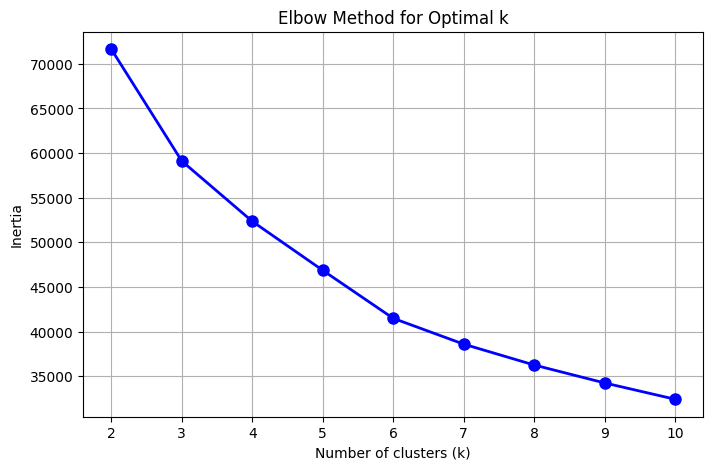

In [23]:
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(K_range)
plt.grid(True)
plt.show()

Silhuotte score

In [25]:
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_df)
    sil_scores.append(silhouette_score(scaled_df, labels))

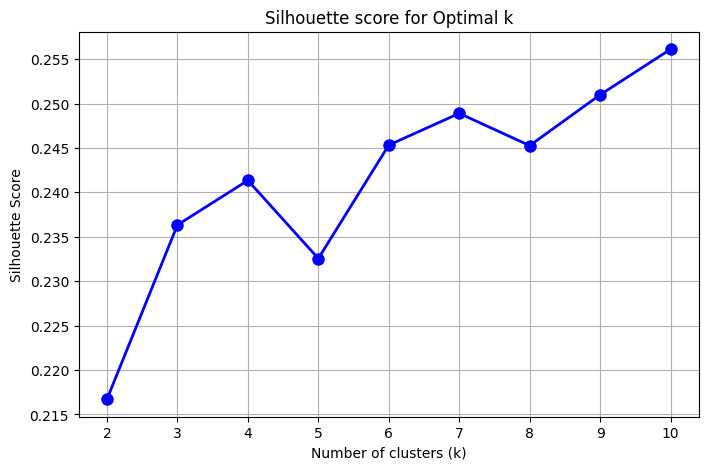

In [26]:
plt.figure(figsize=(8,5))
plt.plot(K_range, sil_scores, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette score for Optimal k')
plt.xticks(K_range)
plt.grid(True)
plt.show()

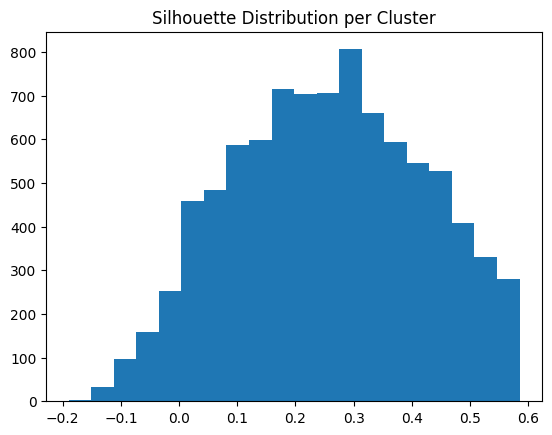

In [28]:
sample_sil = silhouette_samples(scaled_df, labels)
plt.hist(sample_sil, bins=20)
plt.title('Silhouette Distribution per Cluster')
plt.show()

Train the model

In [32]:
data_cl = data.dropna(subset=['CREDIT_LIMIT'])
data_cl


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


In [35]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_df)
data_cl['Cluster'] = clusters


C:\Users\ianbo\AppData\Local\Temp\ipykernel_29132\919282352.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cl['Cluster'] = clusters


Cluster Sanity check

In [38]:
data_cl['Cluster'].value_counts(normalize=True).round(2)


Cluster
2    0.48
0    0.26
1    0.26
Name: proportion, dtype: float64

In [39]:
cluster_profile = data_cl.groupby('Cluster')[features].mean()
cluster_profile


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,
0,2219.227386,0.924255,18.676122,10.644041,8.084390,2037.388576,3995.494932,1632.137084,0.030192,11.295787
1,80.181369,0.650917,439.704542,126.843649,313.337670,56.122598,3151.648703,659.950626,0.342974,11.261498
2,1994.712982,0.971324,1827.510859,1149.302392,678.548671,897.146518,5468.224177,2352.214355,0.120394,11.771889


PCA Distribution

In [41]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(scaled_df)

data_cl['PC1'] = X_pca[:, 0]
data_cl['PC2'] = X_pca[:, 1]

C:\Users\ianbo\AppData\Local\Temp\ipykernel_29132\2222918761.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cl['PC1'] = X_pca[:, 0]
C:\Users\ianbo\AppData\Local\Temp\ipykernel_29132\2222918761.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cl['PC2'] = X_pca[:, 1]


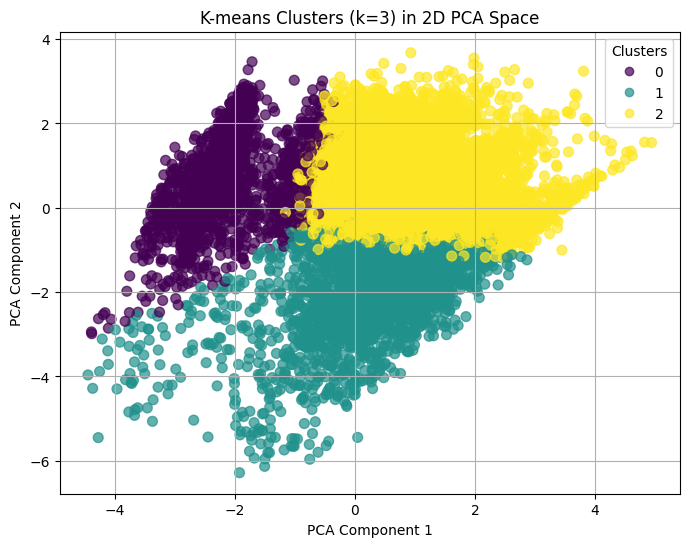

In [ ]:
plt.figure(figsize=(8,6))
scatter = plt.scatter(
    data_cl['PC1'], 
    data_cl['PC2'], 
    c=data_cl['Cluster'],  
    cmap='viridis',   
    s=50,             
    alpha=0.7         
)

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-means Clusters (k=3) in 2D PCA Space')

# Optional: add legend
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.grid(True)
plt.show()

“We applied K-means clustering on log-transformed and standardized behavioral features. Feature redundancy was removed using Spearman correlation to prevent distance distortion. The optimal number of clusters was selected using elbow and silhouette methods. Final clusters were profiled using original-scale feature means to derive actionable customer segments.”

Saving the model

In [44]:
joblib.dump(kmeans, 'Cust_seg_kmeans.pkl')

['Cust_seg_kmeans.pkl']